1. Poder tomar al menos dos variables diferentes de la base de datos.
2. Aparte de las variables, se debe de tomar el nombre (para pruebas futuras donde con los puros datos se identifica que motor es).
3. Se debe de identificar, con fundamentos matemáticos, la linea en dos dimensiones qu mejor separa los datos.
4. EXTRA: Obtener los vectores de soporte, de igual forma, con fundamentación matemática.

NOTA: Este markdown solo reune los pasos a los que se pretende llegar en esta primera prueba. Despues de este markdown no va ninguna sección de código.

[SECCION 1: Tomar variables de la base de datos]
1. Genrerar una estructura llamada 'Motor' cuyos atributos seran: Eng_Type, Fuel_Flow_T/O, Ambient_Temp_Max
2. De la base de datos 'edb-emissions-databank_v31__web_0 (2)' en la carpeta 'Gaseous Emissions and Smoke' tomar los valores de Eng Type, Flow T/O y Ambient Temp Max. para crear 20 estructuras 'Motor'.
3. Los valores tomados deben de ser al azar, no pueden ser consecutivos.
4. Mostrar en una tabla las estructuras, donde las columnas seran: Numero de estructura, Eng Type, Flow T/O, Ambient Temp Max

In [3]:
from dataclasses import dataclass
import pandas as pd

@dataclass
class Motor:
    Eng_Type: str
    Fuel_Flow_TO: float
    Ambient_Temp_Max: float

# Leer datos del archivo Excel
df = pd.read_excel('/workspaces/Aircraft-Engine-Takeoff-ML-Notes/datasets/edb-emissions-databank_v31__web__0 (2).xlsx', sheet_name='Gaseous Emissions and Smoke')

# Crear 20 estructuras Motor con registros aleatorios (no consecutivos)
motors = []
sampled_df = df.sample(20, random_state=42)  # random_state para reproducibilidad
for idx, row in sampled_df.iterrows():
    motor = Motor(
        Eng_Type=row['Eng Type'],
        Fuel_Flow_TO=row['Fuel Flow T/O (kg/sec)'],
        Ambient_Temp_Max=row['Ambient Temp Max (K)']
    )
    motors.append(motor)

# Mostrar tabla
print("Numero | Eng Type | Flow T/O | Ambient Temp Max")
print("-" * 50)
for idx, m in enumerate(motors, 1):
    print(f"{idx:6} | {m.Eng_Type:8} | {m.Fuel_Flow_TO:8.2f} | {m.Ambient_Temp_Max:15.2f}")

Numero | Eng Type | Flow T/O | Ambient Temp Max
--------------------------------------------------
     1 | TF       |     1.80 |          287.00
     2 | TF       |     0.79 |          278.10
     3 | TF       |     0.91 |          297.00
     4 | TF       |     0.77 |          295.00
     5 | TF       |     3.51 |          281.30
     6 | TF       |     2.72 |          303.50
     7 | TF       |     0.71 |          300.80
     8 | TF       |     0.65 |          287.70
     9 | TF       |     0.71 |          278.15
    10 | TF       |     2.37 |          303.50
    11 | TF       |     0.80 |          300.80
    12 | TF       |     2.54 |          296.00
    13 | TF       |     0.76 |          278.10
    14 | TF       |     2.83 |          281.30
    15 | TF       |     2.40 |          290.30
    16 | TF       |     1.01 |          290.50
    17 | MTF      |     0.39 |          313.00
    18 | MTF      |     1.05 |          296.00
    19 | TF       |     2.35 |          296.00
    20 |

5. Generar una grafica donde el eje horizontal representa a la variable Flow_T/O y la variable vertical representa la variable Ambient_Temo_Max. El atributo de Eng_Type es adimensional. La forma de graficar sera con puntos coordenados entre las dos variables que si representan una dimension (Flow_T/O y Ambient_Max_Temp) y la variabe adimensional (Eng_Type) acompaña como texto a los puntos coordenados.

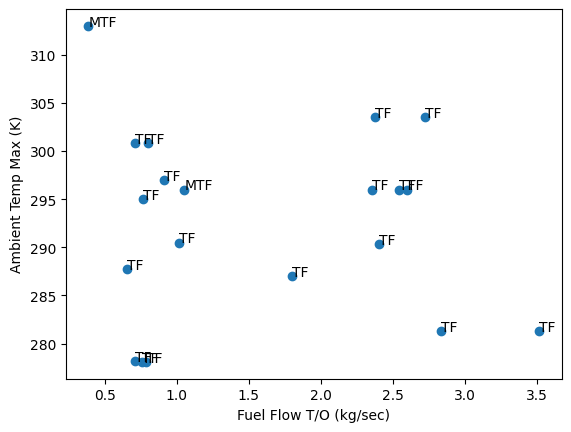

In [4]:
import matplotlib.pyplot as plt

# Asumiendo que 'motors' está definido en la celda anterior
# Si no, ejecutar la celda anterior primero

x = [m.Fuel_Flow_TO for m in motors]
y = [m.Ambient_Temp_Max for m in motors]
labels = [m.Eng_Type for m in motors]

plt.scatter(x, y)
for i, label in enumerate(labels):
    plt.annotate(label, (x[i], y[i]))
plt.xlabel('Fuel Flow T/O (kg/sec)')
plt.ylabel('Ambient Temp Max (K)')
plt.show()

[SECCION 2: Asociar datos reales con conceptos matematicos]
EXPLICACION AL LECTOR -> Es bien sabido que para poder separara los datos en dos grupos (A y B), es necesario encontrar la  que mejor separa los datos. Para conseguir esto se ha de encontrar la recta f(x) = (w)(x) + b. En este caso, W representa los atributos de las estructuras 'Motor', que serían Fuel_Flow_T/O  y Ambient_Max_Temp, y las estructuras por si mismas representan el vector x de agrpación de datos.

De esta forma podemos llevar a f(x)  a su forma de suma: "la suma de todos los atributos almacenados en el vector W de todas las estructuras representadas por x más una constante b"



In [7]:
# Convertir Eng Type: TF = 1, MTF = 0
sampled_df['Eng Type'] = sampled_df['Eng Type'].map({'TF': 1, 'MTF': 0})
print(sampled_df['Eng Type'])

715    1
605    1
120    1
208    1
380    1
817    1
575    1
266    1
557    1
826    1
580    1
327    1
623    1
365    1
765    1
198    1
456    0
465    0
311    1
331    1
Name: Eng Type, dtype: int64


In [8]:
sampled_df

,UID No,GSDB No,Manufacturer,Engine Identification,Combustor Description,Eng Type,B/P Ratio,Pressure Ratio,Rated Thrust (kN),Data Status,...,Final Test Date,Compliance with fuel venting requirements,Remark 1,Remark 2,Remark 3,Remark 4,Remark 5,Remark 6,Remark 7,Remark 8
715,1RR012,1,Rolls-Royce plc,RB211-535C,NaN,1,4.500000,21.500000,163.300000,C,...,1984-05-01,NaN,Data from certification report CRR58085,NaN,NaN,NaN,NaN,NaN,NaN,NaN
605,20PW129,20,Pratt & Whitney,PW1525G,TALON X,1,11.050000,38.670000,108.530000,C,...,2018-03-26,Yes,Data from Certification Report PWA-11600,Block C combustor,"Certification in accordance with Part III, Cha...","NOx levels in accordance with Part III, Chapte...",NaN,NaN,NaN,NaN
120,3CM030,3,CFM International,CFM56-7B20,NaN,1,5.400000,22.610000,91.630000,C,...,NaT,NaN,"FAA Certification Report CR-997, Dec 96.",Engine S/N 874-101/01,NaN,NaN,NaN,NaN,NaN,NaN
208,8GE114,8,General Electric Company,CF34-10E2A1,SAC,1,5.090000,25.100000,75.440000,C,...,2004-07-25,Yes,GE Reports R2004AE636 and R2006AE173,Block 1 Engines,Engine 994-110/1,NaN,NaN,NaN,NaN,NaN
380,9GE128,9,General Electric Company,GE90-94B,PEC,1,8.330000,40.820000,430.920000,C,...,2007-12-08,Yes,GE Aviation Report R2007AE851,Engine serial number 900-505/1,Turbomachinery incorporating 3D aero,Performance Enhanced Combustor (PEC),"Certification in accordance with Part III, Cha...","NOx levels in accordance with Part III, Chapte...",NaN,NaN
817,02P23RR131,23,Rolls-Royce plc,Trent 1000-J3,Phase5 Tiled,1,8.934210,47.955753,350.902441,C,...,2019-08-28,Yes,Representative of Trent 1000-TEN engines,EDNS01000935986,NaN,NaN,NaN,NaN,NaN,NaN
575,01P22PW158,22,Pratt & Whitney,PW1122G-JM,"TALON X, Block-D",1,12.721148,28.776682,107.824385,C,...,2020-01-21,Yes,Data from certification report PWA-12090,1 engine tested,"TALON-X, Block-D combustor",Certification in accordance with ICAO Annex 16...,Same sea level static thrust rating as the PW1...,NaN,NaN,NaN
266,07P27GE226,27,General Electric Company,CF34-8E5,LEC,1,4.724320,23.796747,59.694256,C,...,2023-12-21,Yes,Engine S/N 908-337/1,Ref. GE Report R2023AE234/Rev.0,NaN,NaN,NaN,NaN,NaN,NaN
557,18PW118,18,Pratt & Whitney,PW1124G1-JM,TALON X,1,12.720000,28.780000,107.820000,C,...,2014-03-14,Yes,"Data from Certification Report PWA-11521, 3 en...","Certification in accordance with Part III, Cha...","NOx levels in accordance with Part III, Chapte...",NaN,NaN,NaN,NaN,NaN
826,02P23RR140,23,Rolls-Royce plc,Trent7000-70,Phase5 Tiled,1,9.093380,44.088987,317.772083,C,...,2019-08-28,Yes,Representative of Trent7000 engines,EDNS01000935986,NaN,NaN,NaN,NaN,NaN,NaN
